In [1]:
#Customer Churn prediction Assignment

#Importing Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Create and Prepare Data
#Creating dataset
data = {
    'MonthlyCharge': [50, 80, 70, 40, 90, 60, 100, 85, 45, 75],
    'ContractLength': [12, 6, 24, 12, 3, 18, 24, 6, 12, 18],
    'Age': [30, 25, 40, 35, 28, 50, 45, 32, 29, 55],
    'Churn': [0, 1, 0, 0, 1, 0, 0, 1, 0, 0]  # 0 = No Churn, 1 = Churn
}

# Convert to DataFrame
df = pd.DataFrame(data)
print("Dataset:")
print(df)
print("\nDataset Info:")
print(df.info())
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

Dataset:
   MonthlyCharge  ContractLength  Age  Churn
0             50              12   30      0
1             80               6   25      1
2             70              24   40      0
3             40              12   35      0
4             90               3   28      1
5             60              18   50      0
6            100              24   45      0
7             85               6   32      1
8             45              12   29      0
9             75              18   55      0

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   MonthlyCharge   10 non-null     int64
 1   ContractLength  10 non-null     int64
 2   Age             10 non-null     int64
 3   Churn           10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes
None

Churn Distribution:
Churn
0    7
1    3
Name: count, dtype: int64


In [ ]:
#Separate Features and Target Variable

# Features (X) - independent variables

#Features are input used for prediction

X = df[['MonthlyCharge', 'ContractLength', 'Age']]

# Target (y) - dependent variable (what we want to predict)
y = df['Churn']

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   MonthlyCharge  ContractLength  Age
0             50              12   30
1             80               6   25
2             70              24   40
3             40              12   35
4             90               3   28

Target (y):
0    0
1    1
2    0
3    0
4    1
Name: Churn, dtype: int64


In [14]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")
print("\nTraining set - Churn distribution:")
print(y_train.value_counts())
print("\nTesting set - Churn distribution:")
print(y_test.value_counts())

Training set size: 8 samples
Testing set size: 2 samples

Training set - Churn distribution:
Churn
0    6
1    2
Name: count, dtype: int64

Testing set - Churn distribution:
Churn
0    1
1    1
Name: count, dtype: int64


In [5]:
# Standardize features to have mean=0 and standard deviation=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better visualization (optional)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Scaled Training Features (first 5 rows):")
print(X_train_scaled_df.head())
print("\nMean of scaled features (should be ~0):")
print(X_train_scaled_df.mean())
print("\nStandard deviation of scaled features (should be ~1):")
print(X_train_scaled_df.std())

Scaled Training Features (first 5 rows):
   MonthlyCharge  ContractLength       Age
0      -0.587095        0.464758  1.152549
1      -1.108958       -0.361478 -1.016955
2       0.717561       -1.187715 -0.800005
3      -0.065233        1.290994  0.067797
4       0.195698        0.464758  1.694925

Mean of scaled features (should be ~0):
MonthlyCharge     0.000000e+00
ContractLength   -2.081668e-17
Age               0.000000e+00
dtype: float64

Standard deviation of scaled features (should be ~1):
MonthlyCharge     1.069045
ContractLength    1.069045
Age               1.069045
dtype: float64


In [6]:
# Create and train the model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("Model Training Complete!")
print(f"Intercept (bias): {model.intercept_[0]:.4f}")
print("Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"  {feature}: {coef:.4f}")

Model Training Complete!
Intercept (bias): -1.5366
Coefficients:
  MonthlyCharge: 0.7081
  ContractLength: -0.9411
  Age: -0.5400


In [7]:
# Predict probabilities
y_pred_proba = model.predict_proba(X_test_scaled)
# Predict classes (0 or 1)
y_pred = model.predict(X_test_scaled)

# Create a comparison DataFrame
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability_No_Churn': y_pred_proba[:, 0],
    'Probability_Churn': y_pred_proba[:, 1]
})
print("Test Set Predictions:")
print(results_df)

Test Set Predictions:
   Actual  Predicted  Probability_No_Churn  Probability_Churn
0       0          0              0.826175           0.173825
1       1          1              0.321594           0.678406


In [16]:
# Calculate all metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary')
recall = recall_score(y_test, y_pred, average='binary')
f1 = f1_score(y_test, y_pred, average='binary')
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'])

# Print metrics
print("="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy Score: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision Score: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall Score: {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score: {f1:.4f} ({f1*100:.2f}%)")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

MODEL PERFORMANCE METRICS
Accuracy Score: 1.0000 (100.00%)
Precision Score: 1.0000 (100.00%)
Recall Score: 1.0000 (100.00%)
F1 Score: 1.0000 (100.00%)

Confusion Matrix:
[[1 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00         1
       Churn       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



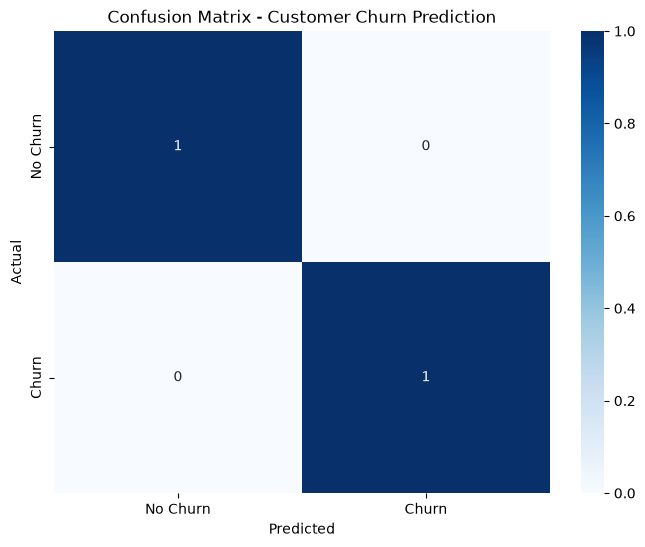

In [9]:
# Create confusion matrix visualization
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Customer Churn Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [10]:
# Feature importance (coefficients)
print("="*50)
print("FEATURE IMPORTANCE INTERPRETATION")
print("="*50)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Impact': ['Positive (↑ Churn)' if c > 0 else 'Negative (↓ Churn)' for c in model.coef_[0]]
})
print(coef_df)

# Probability interpretation
print("\n" + "="*50)
print("PROBABILITY INTERPRETATION")
print("="*50)
# Get a sample prediction
sample = X_test_scaled[0].reshape(1, -1)
prob = model.predict_proba(sample)[0]
print(f"Sample customer prediction:")
print(f"  Probability of NOT churning: {prob[0]*100:.2f}%")
print(f"  Probability of churning: {prob[1]*100:.2f}%")
print(f"  Predicted class: {'Churn' if prob[1] > 0.5 else 'No Churn'}")

FEATURE IMPORTANCE INTERPRETATION
          Feature  Coefficient              Impact
0   MonthlyCharge     0.708108  Positive (↑ Churn)
1  ContractLength    -0.941075  Negative (↓ Churn)
2             Age    -0.539964  Negative (↓ Churn)

PROBABILITY INTERPRETATION
Sample customer prediction:
  Probability of NOT churning: 82.62%
  Probability of churning: 17.38%
  Predicted class: No Churn


In [11]:
print("="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"Dataset size: {len(df)} customers")
print(f"Features used: {', '.join(X.columns)}")
print(f"Target variable: Churn (0=No, 1=Yes)")
print(f"Model: Logistic Regression")
print(f"Train/Test split: 80%/20%")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1 Score: {f1*100:.2f}%")

# Business interpretation
print("\nBUSINESS INSIGHTS:")
if precision > recall:
    print("• Higher precision than recall - When we predict churn, we're usually right")
    print("  (Fewer false alarms, but we might miss some churners)")
elif recall > precision:
    print("• Higher recall than precision - We catch most churners")
    print("  (Fewer missed churners, but we might have more false alarms)")
else:
    print("• Balanced precision and recall")

# Feature interpretation
print("\nKEY DRIVERS OF CHURN:")
for feature, coef in zip(X.columns, model.coef_[0]):
    if coef > 0:
        print(f"• Higher {feature} → Higher chance of churn (increase by {abs(coef):.3f} in log-odds)")
    else:
        print(f"• Higher {feature} → Lower chance of churn (decrease by {abs(coef):.3f} in log-odds)")

FINAL SUMMARY
Dataset size: 10 customers
Features used: MonthlyCharge, ContractLength, Age
Target variable: Churn (0=No, 1=Yes)
Model: Logistic Regression
Train/Test split: 80%/20%
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%

BUSINESS INSIGHTS:
• Balanced precision and recall

KEY DRIVERS OF CHURN:
• Higher MonthlyCharge → Higher chance of churn (increase by 0.708 in log-odds)
• Higher ContractLength → Lower chance of churn (decrease by 0.941 in log-odds)
• Higher Age → Lower chance of churn (decrease by 0.540 in log-odds)


In [ ]:
# Example: Predict for new customers
new_customers = pd.DataFrame({
    'MonthlyCharge': [65, 95, 55],
    'ContractLength': [12, 3, 24],
    'Age': [33, 27, 42]
})

print("="*50)
print("PREDICTIONS FOR NEW CUSTOMERS")
print("="*50)
print("New Customers:")
print(new_customers)

# Scale the new customers using the same scaler
new_customers_scaled = scaler.transform(new_customers)

# Make predictions
new_predictions = model.predict(new_customers_scaled)
new_probabilities = model.predict_proba(new_customers_scaled)

# Display results
for i, (pred, prob) in enumerate(zip(new_predictions, new_probabilities)):
    print(f"\nCustomer {i+1}:")
    print(f"  Monthly Charge: ${new_customers.iloc[i]['MonthlyCharge']}")
    print(f"  Contract Length: {new_customers.iloc[i]['ContractLength']} months")
    print(f"  Age: {new_customers.iloc[i]['Age']}")
    print(f"  Churn Probability: {prob[1]*100:.2f}%")
    print(f"  Prediction: {'WILL CHURN' if pred == 1 else 'WILL STAY'}")
    if prob[1] > 0.7:
        print("  Risk Level: HIGH ")
    elif prob[1] > 0.4:
        print("  Risk Level: MEDIUM ")
    else:
        print("  Risk Level: LOW ")

PREDICTIONS FOR NEW CUSTOMERS
New Customers:
   MonthlyCharge  ContractLength  Age
0             65              12   33
1             95               3   27
2             55              24   42

Customer 1:
  Monthly Charge: $65
  Contract Length: 12 months
  Age: 33
  Churn Probability: 25.85%
  Prediction: WILL STAY
  Risk Level: LOW 🟢

Customer 2:
  Monthly Charge: $95
  Contract Length: 3 months
  Age: 27
  Churn Probability: 82.81%
  Prediction: WILL CHURN
  Risk Level: HIGH 🔴

Customer 3:
  Monthly Charge: $55
  Contract Length: 24 months
  Age: 42
  Churn Probability: 2.91%
  Prediction: WILL STAY
  Risk Level: LOW 🟢
